In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class LinearRegression() :

    def __init__(self, learning_rate, iterations) :
        # сохраняем параметры во внутренние переменные
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        
    def fit(self, X, Y) :
        # классический метод для тренировки
        # инициализируем веса и смещение
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # нормализация данных для стабильности градиентного спуска
        self.X_mean = np.mean(X, axis=0)
        self.X_std = np.std(X, axis=0)
        X_normalized = (X - self.X_mean) / self.X_std
        
        for i in range(self.iterations) :
            self.update_weights(X_normalized, Y)
            
        return self
    
    def update_weights(self, X, Y) :
        # метод для изменения весов
        n_samples = X.shape[0]
        
        # линейные предсказания
        Y_pred = np.dot(X, self.weights) + self.bias
        
        # вычисляем градиенты
        dw = (1/n_samples) * np.dot(X.T, (Y_pred - Y))
        db = (1/n_samples) * np.sum(Y_pred - Y)
        
        # обновляем веса и смещение
        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db
        
        return self
    
    def predict(self, X) :
        # предсказание значений
        # нормализуем входные данные
        X_normalized = (X - self.X_mean) / self.X_std
        return np.dot(X_normalized, self.weights) + self.bias

Веса (weights): 26366.04
Смещение (bias): 75999.72


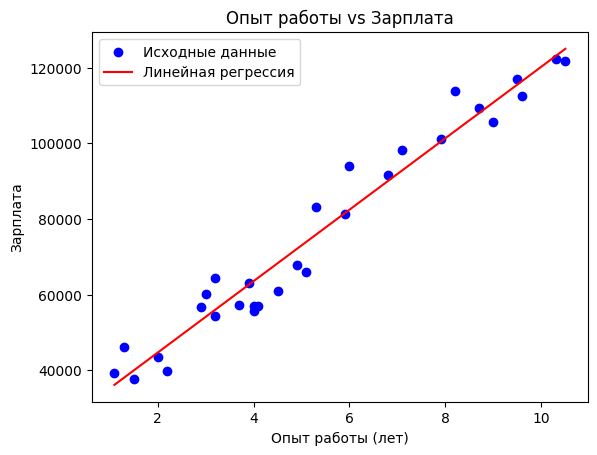


Среднеквадратичная ошибка (MSE): 31270963.78


In [2]:
# Загрузка и подготовка данных
# Примечание: сначала скачайте файл salary_data.csv по ссылке
df = pd.read_csv("/Users/phil/GitHub/masters_degree_Roshchin_M25-555/ML/salary_data.csv")

X = df.iloc[:,:-1].values
Y = df.iloc[:,1].values

# Создаем и обучаем модель
model = LinearRegression(iterations = 1000, learning_rate = 0.01)
model.fit(X, Y)

# Делаем предсказания
Y_pred = model.predict(X)

print("Веса (weights):", *np.round(model.weights, 2))
print("Смещение (bias):", np.round(model.bias, 2))

# Дополнительно: визуализация результатов
plt.scatter(X, Y, color = 'blue', label='Исходные данные')
plt.plot(X, Y_pred, color = 'red', label='Линейная регрессия')
plt.title('Опыт работы vs Зарплата')
plt.xlabel('Опыт работы (лет)')
plt.ylabel('Зарплата')
plt.legend()
plt.show()

# Вычисление метрики MSE
mse = np.mean((Y - Y_pred) ** 2)
print(f"\nСреднеквадратичная ошибка (MSE): {mse:.2f}")